C:\Users\megan\AppData\Local\Temp\ipykernel_39132\3402941210.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetimes = pd.to_datetime(df["datetime"], errors="coerce")


Parsed rows: 9581
State vector shape: (9581, 6)
          jd                        datetime             x             y  \
0  2451544.5  A.D. 2000-Jan-01 00:00:00.0000 -2.521093e+07  1.449279e+08   
1  2451545.5  A.D. 2000-Jan-02 00:00:00.0000 -2.778512e+07  1.444554e+08   
2  2451546.5  A.D. 2000-Jan-03 00:00:00.0000 -3.035080e+07  1.439377e+08   
3  2451547.5  A.D. 2000-Jan-04 00:00:00.0000 -3.290715e+07  1.433751e+08   
4  2451548.5  A.D. 2000-Jan-05 00:00:00.0000 -3.545332e+07  1.427676e+08   

            z         vx        vy        vz  
0 -616.416572 -29.839833 -5.207634  0.000062  
1 -600.751417 -29.746268 -5.730627  0.000299  
2 -565.193249 -29.643017 -6.252175  0.000521  
3 -511.446107 -29.530069 -6.772022  0.000719  
4 -441.880095 -29.407426 -7.289907  0.000886  


C:\Users\megan\AppData\Local\Temp\ipykernel_39132\3402941210.py:73: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetimes = pd.to_datetime(df["datetime"], errors="coerce")


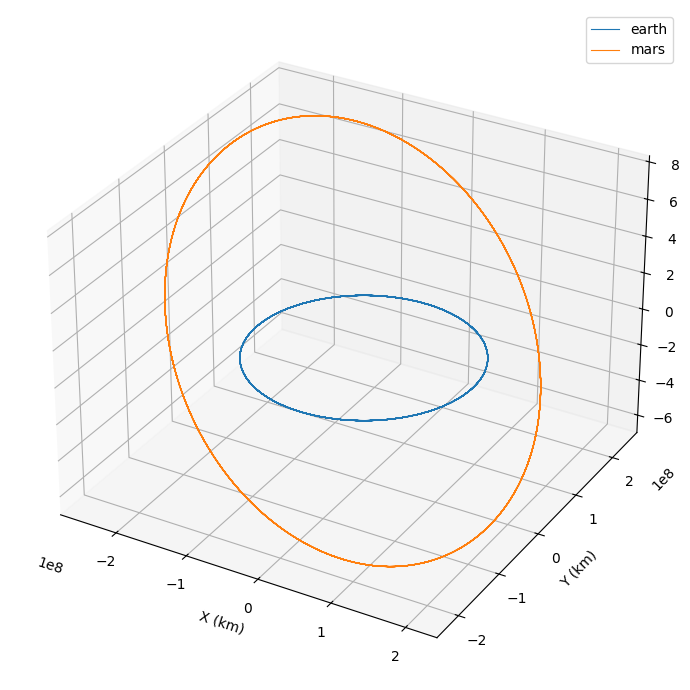

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = "../src/horizons_results_earth_heliocentric_state_vector.txt"

rows = []
pattern = re.compile(
    r'^\s*([0-9.]+),\s*([^,]+?),\s*'
    r'([+-]?\d+(?:\.\d+)?[Ee][+-]?\d+|[+-]?\d+(?:\.\d+)?)\s*,\s*'
    r'([+-]?\d+(?:\.\d+)?[Ee][+-]?\d+|[+-]?\d+(?:\.\d+)?)\s*,\s*'
    r'([+-]?\d+(?:\.\d+)?[Ee][+-]?\d+|[+-]?\d+(?:\.\d+)?)\s*,\s*'
    r'([+-]?\d+(?:\.\d+)?[Ee][+-]?\d+|[+-]?\d+(?:\.\d+)?)\s*,\s*'
    r'([+-]?\d+(?:\.\d+)?[Ee][+-]?\d+|[+-]?\d+(?:\.\d+)?)\s*,\s*'
    r'([+-]?\d+(?:\.\d+)?[Ee][+-]?\d+|[+-]?\d+(?:\.\d+)?)'
)

with open(path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        m = pattern.match(line)
        if m:
            jd = float(m.group(1))
            dt_str = m.group(2).strip()
            x, y, z, vx, vy, vz = map(float, m.groups()[2:])
            rows.append([jd, dt_str, x, y, z, vx, vy, vz])

df = pd.DataFrame(rows, columns=["jd", "datetime", "x", "y", "z", "vx", "vy", "vz"])

state_vectors = df[["x", "y", "z", "vx", "vy", "vz"]].to_numpy()
datetimes = pd.to_datetime(df["datetime"], errors="coerce")

print("Parsed rows:", len(df))
print("State vector shape:", state_vectors.shape)
print(df.head())

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot(df["x"], df["y"], df["z"], lw=0.8, label='earth')
# ax.scatter(df["x"].iloc[0], df["y"].iloc[0], df["z"].iloc[0], c="green", s=40, label="start")
# ax.scatter(df["x"].iloc[-1], df["y"].iloc[-1], df["z"].iloc[-1], c="red", s=40, label="end")
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")


path = "../src/horizons_results_mars_heliocentric_state_vector.txt"


rows = []
pattern = re.compile(
    r'^\s*([0-9.]+),\s*([^,]+?),\s*'
    r'([+-]?\d+(?:\.\d+)?[Ee][+-]?\d+|[+-]?\d+(?:\.\d+)?)\s*,\s*'
    r'([+-]?\d+(?:\.\d+)?[Ee][+-]?\d+|[+-]?\d+(?:\.\d+)?)\s*,\s*'
    r'([+-]?\d+(?:\.\d+)?[Ee][+-]?\d+|[+-]?\d+(?:\.\d+)?)\s*,\s*'
    r'([+-]?\d+(?:\.\d+)?[Ee][+-]?\d+|[+-]?\d+(?:\.\d+)?)\s*,\s*'
    r'([+-]?\d+(?:\.\d+)?[Ee][+-]?\d+|[+-]?\d+(?:\.\d+)?)\s*,\s*'
    r'([+-]?\d+(?:\.\d+)?[Ee][+-]?\d+|[+-]?\d+(?:\.\d+)?)'
)

with open(path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        m = pattern.match(line)
        if m:
            jd = float(m.group(1))
            dt_str = m.group(2).strip()
            x, y, z, vx, vy, vz = map(float, m.groups()[2:])
            rows.append([jd, dt_str, x, y, z, vx, vy, vz])

df = pd.DataFrame(rows, columns=["jd", "datetime", "x", "y", "z", "vx", "vy", "vz"])

state_vectors = df[["x", "y", "z", "vx", "vy", "vz"]].to_numpy()
datetimes = pd.to_datetime(df["datetime"], errors="coerce")

ax.plot(df["x"], df["y"], df["z"], lw=0.8, label='mars')
# ax.scatter(df["x"].iloc[0], df["y"].iloc[0], df["z"].iloc[0], c="green", s=40, label="start")
# ax.scatter(df["x"].iloc[-1], df["y"].iloc[-1], df["z"].iloc[-1], c="red", s=40, label="end")

ax.legend()
plt.tight_layout()
plt.show()